In [40]:
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as integrate

%load_ext autoreload
%autoreload 2

from GP_code import simulate_population_single, get_mean_trajectory_single, simulate_population_double, get_mean_trajectory_double



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate
    mu = 0.08 # Death rate increases over time
    return l, mu

In [42]:
#True value: E[Z(t)]
import scipy.integrate as integrate

def func(t):
    return (0.05 * np.sin(0.1 * t) + 0.1) - 0.08

def func_sens(t):
    return np.exp(0.05/0.1 + (0.1-0.08)*t - (0.05/0.1)*np.cos(0.1*t)) * (0.05*np.sin(0.1 * t) + 0.1)


def calc_expectation(Z0, func, t):
    value, error = Z0 * np.exp(integrate.quad(func, 0, t))
    return value

def calc_cell_division(func_sens, t):
    '''
    Top right of page 183
    '''
    
    value, error = integrate.quad(func_sens, 0, t)
    return value



In [43]:
vals = np.linspace(0, 250, 250)
store = np.zeros(len(vals))
for i, _ in enumerate(vals):
    store[i] = calc_expectation(1, func, _)
    

Fig 1(a): E[Y(t)]: Expected number of sensitive cells for a single-type non-homogenous birth-death process

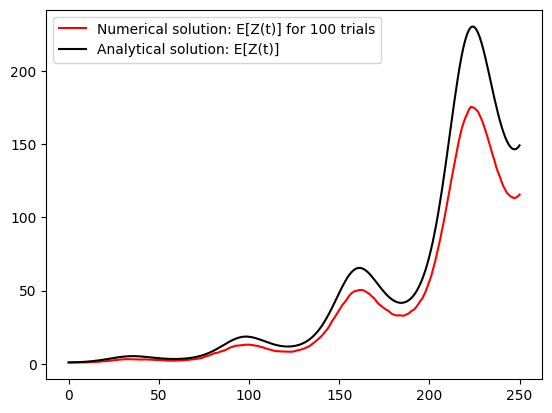

In [44]:
N = 100 #Number of trials
grid, mean_pop, mean_divs = get_mean_trajectory_single(N, 250, 1, example_rates_single, 0.3)
plt.plot(grid, mean_pop, c = 'red', label = f'Numerical solution: E[Z(t)] for {N} trials' )
plt.plot(vals, store, c = 'black', linestyle = '-', label = 'Analytical solution: E[Z(t)]')
plt.legend()

plt.show()

Fig 1 (b): birth-death rate over time

<Axes: >

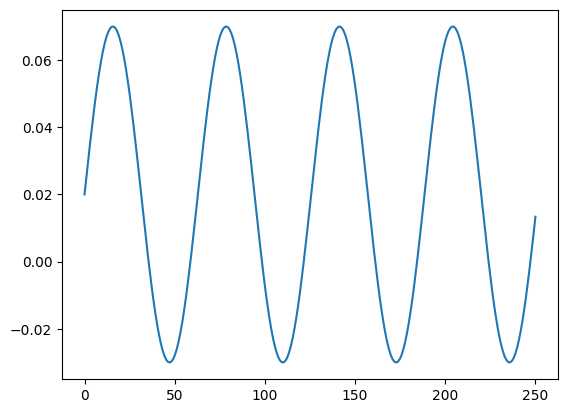

In [45]:
time = np.linspace(0, 250, 250)
y_axis = np.zeros(len(time))
for i, n in enumerate(time):
    y_axis[i] = func(n)

sns.lineplot(x = time, y = y_axis)

In [46]:
vals_c = np.linspace(0, 250, 250)
store_c = np.zeros(len(vals_c))
for i, _ in enumerate(vals_c):
    store_c[i] = calc_cell_division(func_sens, _)

Fig 1(c): Number of sensitive cell divisions

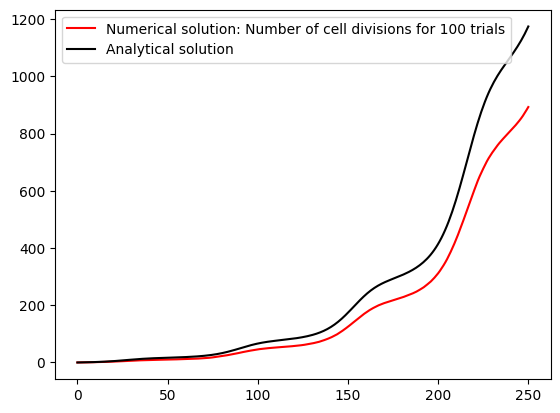

In [47]:
plt.plot(grid, mean_divs, c = 'red', label = f'Numerical solution: Number of cell divisions for {N} trials' )
plt.plot(vals_c, store_c, c = 'black', linestyle = '-', label = 'Analytical solution')
plt.legend()

plt.show()

Fig 1(extra): Variance

In [48]:
# def w_tau(tau):
#     value, error
#     return 0

Fig 2(a): Expected number of resistant cells

In [49]:
def example_rates_double(t, B1, C2):
    # Example: rates depend on drug concentration
    l_x = 0.05 * np.sin(0.1 * t) + B1 # Birth rate sensitive cells
    l_y = 0.05 * np.sin(0.1 * t) + 0.12 # Birth rate resistant cells
    mu_x = 0.14 # death rate of sensitive cells
    mu_y = C2 # death rate of resistant cells
    return l_x, l_y, mu_x, mu_y

In [50]:
#Define analytical result of expected size of resistant cell population
#l_x = 0.05sin(0.1t)+0.1
#mu_x = 0.14
#l_y = 0.05sin(0.1t)+0.12
#mu_y = [0.09, 0.1, 0.11]
#M = 100
#u = 10**-3
def b_tau(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def R_t(t, C2):
    def integral(tau):
        #b_tau(t)
        term1 = (0.05/0.1)*np.cos(0.1*tau) - (0.05/0.1)*np.cos(0.1*t) + (0.12-C2)*t +(C2-0.12)*tau
        func = b_tau(tau)*np.exp(term1)
        return func
    value, error = integrate.quad(integral, 0, t)
    return value

In [51]:
N = 200 #Number of trials
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
B1 = 0.1
#C2 = 0.09
for C2 in [0.09, 0.1, 0.11]:
    grid, mean_pop, mean_r, probs = get_mean_trajectory_double(N, T_max, M0, R0, example_rates_double, beta, u, B1, C2)
    plt.plot(grid, mean_r, c = 'red', label = f'Numerical solution: {N} trials, C2 = {C2}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = R_t(_, C2)
    plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Analytical solution: R(t)')
    plt.legend()

plt.show()

ValueError: too many values to unpack (expected 4)

Fig 2(b): Probability of Resistance

In [ ]:
#b_tau already defined
#We are looking for P_r(T) = 1- exp(integral(-b + b * P_ext dt)from 0 T)
#define p_ext as Q/1+Q
def b_t(tau):
    term1 = (0.05/0.1) + ((0.1 - 0.14)*tau) - ((0.05/0.1)*np.cos(0.1*tau))
    term2 = (0.05*np.sin(0.1*tau) + 0.1)*1e-3
    return 100 * np.exp(term1)*term2

def P_rt (t, T, B1):
    def P_exp():
        def integral(t, T):
            def Q(tau):
                #b_tau(t)
                term1 = (0.05/0.1)*np.cos(0.1*(tau+t)) - (0.05/0.1)*np.cos(0.1*t) - (0.1)*tau
                func = 0.1*np.exp(term1)
                return func
            value, error = integrate.quad(Q, 0, T-t)
            return value
        p_exp = integral/(1+integral)
        return p_exp
    term = -b_t(t) + (b_t(t) * P_exp)
    value, error = integrate.quad(term, 0, T)
    return 1 - np.exp(value)

In [ ]:
M = 100
u = 1e-3
theta = 0.1
A = 0.05
C1 = 0.14
B2, C2 = 0.12, 0.1 

def get_b_t(t, B1):
    # This is b(t): the rate of production of resistant cells at time t
    # Integral of (l_x - mu_x) = (A/y) - (A/y)cos(yt) + (B1-C1)t
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def get_Q(t, T):
    # Q is the integral from 0 to (T-t)
    def Q_integrand(tau):
        # Integral of (l_y - mu_y) from t to t+tau
        # = [-(A/y)cos(y*zeta) + (B2-C2)zeta] evaluated from t to t+tau
        # term_future = -(A/theta)*np.cos(theta*(t + tau)) + (B2 - C2)*tau
        # term_birth = -(A/theta)*np.cos(theta*t)
        # # Note: (B2-C2)*t is NOT in the exponent for the 'relative' growth 
        # # because we are integrating from t to t+tau
        # growth_exponent = term_future - term_birth + (B2 - C2)*t
        
        # Actually, based on your paper's Q formula:
        # A2/y*cos(y(t+tau)) - A2/y*cos(yt) + (B2-C2)tau
        # Let's follow your specific Q formula precisely:
        q_exp = (A/theta)*np.cos(theta*(t+tau)) - (A/theta)*np.cos(theta*t) - (B2 - C2)*tau
        return C2 * np.exp(q_exp)

    val, _ = integrate.quad(Q_integrand, 0, T - t)
    return val

def get_P_ext(t, T):
    Q_val = get_Q(t, T)
    return Q_val / (1 + Q_val)

def P_R(T, B1):
    # Final integral from 0 to T of [-b(t) + b(t)*P_ext(t,T)]
    def final_integrand(t):
        bt = get_b_t(t, B1)
        pext = get_P_ext(t, T)
        return -bt + (bt * pext)

    integral_val, _ = integrate.quad(final_integrand, 0, T)
    return 1 - np.exp(integral_val)

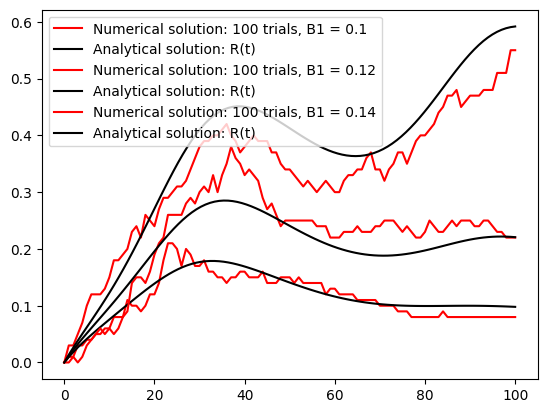

In [ ]:
N = 100 #Number of trials. Need a lot for this
T_max = 100
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1
for B1 in [0.1, 0.12, 0.14]:
    grid, mean_pop, mean_r, probs = get_mean_trajectory_double(N, T_max, M0, R0, 
                                                               example_rates_double, beta, u, B1, C2)
    plt.plot(grid, probs, c = 'red', label = f'Numerical solution: {N} trials, B1 = {B1}' )

    vals_r = np.linspace(0, 100, 100)
    store_r = np.zeros(len(vals_r))
    for i, _ in enumerate(vals_r):
        store_r[i] = P_R(_, B1)
    plt.plot(vals_r, store_r, c = 'black', linestyle = '-', label = 'Analytical solution: R(t)')
    plt.legend()

plt.show()

Fig 2(c): Variance of resistant cell population

In [ ]:
#Analytical solution
#need to define lamba_y, w_hat, and b.
#we can use b as per above
A = 0.05
theta = 0.1
B1 = 0.1
B2 = 0.12
C1 = 0.14
C2 = 0.1

M = 100
u = 1e-3


def get_b_t(t):
    # This is b(t): the rate of production of resistant cells at time t
    # Integral of (l_x - mu_x) = (A/y) - (A/y)cos(yt) + (B1-C1)t
    exponent = (A/theta) - (A/theta)*np.cos(theta*t) + (B1 - C1)*t
    S_t = M * np.exp(exponent)
    l_x_t = A * np.sin(theta*t) + B1
    return S_t * l_x_t * u

def lambda_y(z):
    #z = tau + t
    result = A * np.sin(theta * z) + B2
    return result

def w_hat(o, t):
    #o can be tau, T-t, etc.
    def integrand(n):
        return C2 - lambda_y((n+t))
    integ, _ = integrate.quad(integrand, 0, o)
    return np.exp(integ)

def integ_1(t, T):
    #integral within variance integral
    #integral of w(tau, t) * lambdaY(tau + t) dtau from 0 to T-t
    def integrand(tau):
        z = tau + t
        term = w_hat(tau, t) * lambda_y(z)
        return term
    value, _ = integrate.quad(integrand, 0, (T-t))
    return value

def var_R(T):
    #Variance of population of resistance cells
    def integrand(t):
        o = T-t
        w = w_hat(o, t)
        numerator = get_b_t(t) * (w + (2 * integ_1(t, T)))
        denominator = w**2
        full = numerator / denominator
        return full
    value, _ = integrate.quad(integrand, 0, T)
    return value

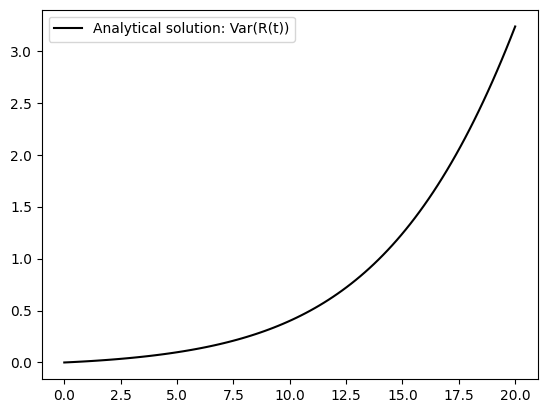

In [ ]:
T = 20

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_R(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Analytical solution: Var(R(t))')
plt.legend()
plt.show()

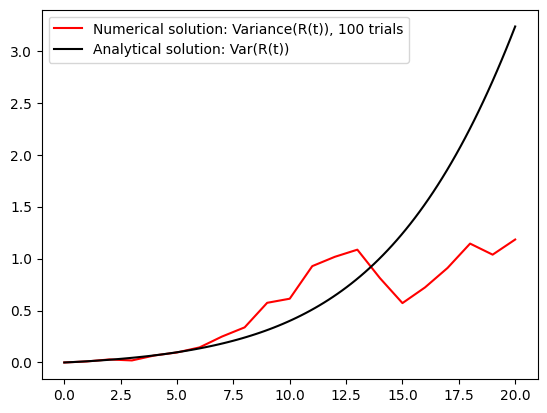

In [54]:
N = 100 #Number of trials. Need a lot for this (~5000)
T = 20
M0 = 100
R0 = 0
beta = 0.7
u = 1e-3
C2 = 0.1
B1 = 0.1
grid, mean_pop, mean_r, probs, var = get_mean_trajectory_double(N, T, M0, R0, 
                                                            example_rates_double, beta, u, B1, C2)
plt.plot(grid, var, c = 'red', label = f'Numerical solution: Variance(R(t)), {N} trials' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_R(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Analytical solution: Var(R(t))')
plt.legend()


plt.show()

For large N i can match analytical result, so I don't think the issue is on my side. var at T = 20 should be ~ 4, but I get ~3.2. Could be parameter issue, need to check these. Maybe find a more general way to do it

In [55]:
#----------------------------

Look at single type Var, as Ruby \& Janet noticed issues

In [58]:
#Analytical solution for single-type as per paper

In [80]:
#parameters as per Fig 1a
A = 0.05
theta = 0.1
B = 0.1
C = 0.08
M0 = 1

#function for numerical solution
def example_rates_single(t):
    # Example: rates depend on drug concentration
    l = A * np.sin(theta * t) + B # Birth rate
    mu = C # Death rate increases over time
    return l, mu

#--------------------------------------------------------

#Analytical solution
def lamb(t):
    return A * np.sin(theta * t) + B

def mu(t):
    return C

def w(tau):
    def integrand(neb):
        return  mu(neb) - lamb(neb)
    value, error = integrate.quad(integrand, 0, tau)
    return np.exp(value)

def var_single(t):
    def integrand(tau):
        return (lamb(tau) + mu(tau)) * w(tau)
    value, error = integrate.quad(integrand, 0, t)
    return M0 * w(t)**(-2) * value
        

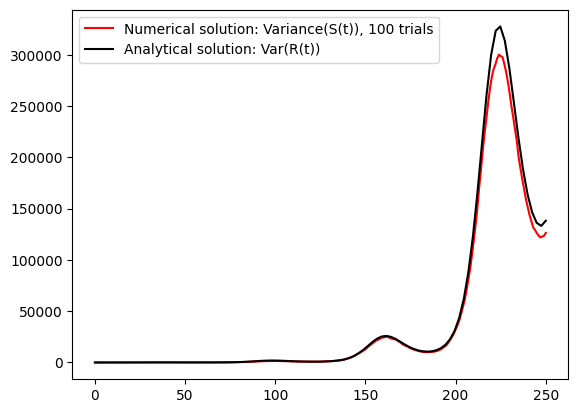

In [82]:
N = 100 #Number of trials. Need a lot for this (~5000)
T = 250
beta = 0.7





grid, mean_pop, mean_r, var = get_mean_trajectory_single(N, T, M0, example_rates_single, beta)
plt.plot(grid, var, c = 'red', label = f'Numerical solution: Variance(S(t)), {N} trials' )

vals_v = np.linspace(0, T, 100)
store_v = np.zeros(len(vals_v))
for i, _ in enumerate(vals_v):
    store_v[i] = var_single(_)
plt.plot(vals_v, store_v, c = 'black', linestyle = '-', label = 'Analytical solution: Var(R(t))')
plt.legend()


plt.show()

In [76]:
store_v[-1]


np.float64(0.005968558454861964)

In [67]:
l, mu, t = 0.1, 0.08, 250
approx_var = (l + mu)/(l - mu) * np.exp((l-mu)*t) * (np.exp((l-mu)*t) - 1)
print(approx_var)  # will be very large

196902.4737213376


**Var[Z(t)]**
The paper has definitley made a mistake. Ruby has derived the correct analytical solution, which perfectly matches the numerical solution, (which I have faith in).
Need to track the process. I originally tried the papers solution. Staggering difference. \
Give the net positive rate, the variance should be large. The issue is that they should have excluded the exponential in w(t) or included it, but removed from the final; equation. \
Can show that we also checked the approximate variance and showed that it should be large. 